In [1]:
%load_ext autoreload 
%autoreload 2

In [2]:
import torch 
import numpy as np
import matplotlib.pyplot as plt
import networkx as nx
from fugw.mappings import FUGW
import os
os.environ["CUDA_VISIBLE_DEVICES"] = "3"

In [13]:
# 随机生成一个基础图G1
num_nodes = 20
prob_edge = 0.3
G1 = nx.erdos_renyi_graph(num_nodes, prob_edge, seed=42)

# 生成G2: 在G1的基础上，轻微扰动（添加/删除一些边，节点的标签打乱）
import random
G2 = G1.copy()

# 随机添加/删除部分边
edges = list(G2.edges())
nodes = list(G2.nodes())
random.seed(42)
num_perturb = max(1, num_nodes // 10)

# 随机删除一些边
for _ in range(num_perturb):
    if edges:
        e = random.choice(edges)
        G2.remove_edge(*e)
        edges.remove(e)

# 随机添加一些边
for _ in range(num_perturb):
    n1, n2 = random.sample(nodes, 2)
    if not G2.has_edge(n1, n2):
        G2.add_edge(n1, n2)

# 节点重标号（可选，增加相似性挑战）
mapping = dict(zip(G2.nodes(), random.sample(nodes, len(nodes))))
G2 = nx.relabel_nodes(G2, mapping)

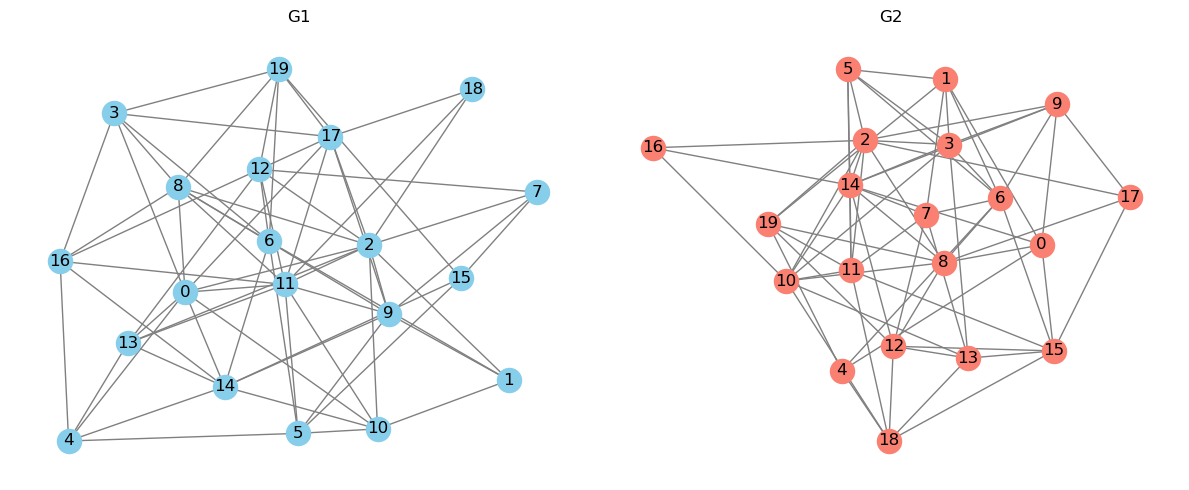

In [14]:
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
nx.draw(G1, with_labels=True, node_color='skyblue', edge_color='gray')
plt.title("G1")

plt.subplot(1, 2, 2)
nx.draw(G2, with_labels=True, node_color='salmon', edge_color='gray')
plt.title("G2")

plt.tight_layout()
plt.show()


In [3]:
# toy features (n_features, n_points)
n_features, n_points = 2, 50
sf = torch.randn(n_features, n_points)
tf = torch.randn(n_features, n_points)

# normalize features (官方示例强烈建议)
sf = sf / torch.linalg.norm(sf, dim=1).reshape(-1,1)
tf = tf / torch.linalg.norm(tf, dim=1).reshape(-1,1)

# 权重（必须为长度匹配的向量）
a = torch.rand(n_points)  # shape (n,)
b = torch.rand(n_points)  # shape (m,)
a = a/a.sum()
b = b/b.sum()

# toy geometries (distance matrices)
Xs = torch.rand(n_points, 2)
Ys = torch.rand(n_points, 2)
Ds = torch.cdist(Xs, Xs) ** 2  # squared distances
Dt = torch.cdist(Ys, Ys) ** 2

model = FUGW(alpha=0.5, rho=1.0, eps=1e-4)
model.fit(
    source_features=sf,
    target_features=tf,
    source_geometry=Ds,
    target_geometry=Dt,
    source_weights=a,
    target_weights=b,
    solver='sinkhorn',
    solver_params={'tol_uot': 1e-10},
    device='auto',
    verbose=True
)

pi = model.pi  # coupling (torch tensor)
mapped = model.transform(sf)

[10:13:42] Validation data for feature maps is not provided. Using training data instead.              ]8;id=217882;file:///home/bcl/wanghongyu/.conda/envs/network/lib/python3.11/site-packages/fugw/mappings/dense.py\dense.py]8;;\:]8;id=777428;file:///home/bcl/wanghongyu/.conda/envs/network/lib/python3.11/site-packages/fugw/mappings/dense.py#199\199]8;;\

           Validation data for anatomical kernels is not provided. Using training data instead.        ]8;id=37474;file:///home/bcl/wanghongyu/.conda/envs/network/lib/python3.11/site-packages/fugw/mappings/dense.py\dense.py]8;;\:]8;id=953887;file:///home/bcl/wanghongyu/.conda/envs/network/lib/python3.11/site-packages/fugw/mappings/dense.py#226\226]8;;\

Output()

Output()

[10:13:43] BCD step 1/10   FUGW loss:      0.06300435215234756     Validation loss:                    ]8;id=679350;file:///home/bcl/wanghongyu/.conda/envs/network/lib/python3.11/site-packages/fugw/solvers/dense.py\dense.py]8;;\:]8;id=87910;file:///home/bcl/wanghongyu/.conda/envs/network/lib/python3.11/site-packages/fugw/solvers/dense.py#521\521]8;;\
           0.06300435215234756                                                                                     

...

Output()

           BCD step 9/10   FUGW loss:      0.03470288962125778     Validation loss:                    ]8;id=727957;file:///home/bcl/wanghongyu/.conda/envs/network/lib/python3.11/site-packages/fugw/solvers/dense.py\dense.py]8;;\:]8;id=334212;file:///home/bcl/wanghongyu/.conda/envs/network/lib/python3.11/site-packages/fugw/solvers/dense.py#521\521]8;;\
           0.03470288962125778                                                                                     

Output()

Output()

[10:13:48] BCD step 10/10  FUGW loss:      0.034700799733400345    Validation loss:                    ]8;id=705852;file:///home/bcl/wanghongyu/.conda/envs/network/lib/python3.11/site-packages/fugw/solvers/dense.py\dense.py]8;;\:]8;id=10758;file:///home/bcl/wanghongyu/.conda/envs/network/lib/python3.11/site-packages/fugw/solvers/dense.py#521\521]8;;\
           0.034700799733400345                                                                                    

In [9]:
model.loss
for k in model.loss.keys():
    print(k, len(model.loss[k]), type(model.loss[k]))


wasserstein 11 <class 'list'>
gromov_wasserstein 11 <class 'list'>
marginal_constraint_dim1 11 <class 'list'>
marginal_constraint_dim2 11 <class 'list'>
regularization 11 <class 'list'>
total 11 <class 'list'>


Text(0, 0.5, 'Source Index')

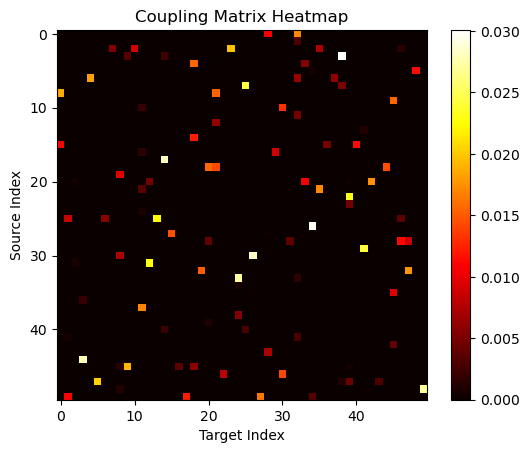

In [20]:
plt.imshow(pi.cpu().detach().numpy(), cmap='hot', interpolation='nearest')
plt.colorbar()
plt.title("Coupling Matrix Heatmap")
plt.xlabel("Target Index")
plt.ylabel("Source Index")